In [45]:
!pip install pandas
!pip install matplotlib
!pip install seaborn
!pip install -U scikit-learn

You should consider upgrading via the 'c:\users\my pc\appdata\local\programs\python\python37\python.exe -m pip install --upgrade pip' command.


You should consider upgrading via the 'c:\users\my pc\appdata\local\programs\python\python37\python.exe -m pip install --upgrade pip' command.


You should consider upgrading via the 'c:\users\my pc\appdata\local\programs\python\python37\python.exe -m pip install --upgrade pip' command.


Requirement already up-to-date: scikit-learn in c:\users\my pc\appdata\local\programs\python\python37\lib\site-packages (1.0.2)


You should consider upgrading via the 'c:\users\my pc\appdata\local\programs\python\python37\python.exe -m pip install --upgrade pip' command.


In [46]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
titanic_data=pd.read_csv("D:/titanic survival/Titanic-Dataset.csv")

In [47]:
from sklearn.model_selection import StratifiedShuffleSplit
split=StratifiedShuffleSplit(n_splits=1, test_size=0.2)
for train_indices, test_indices in split.split(titanic_data,titanic_data[['Survived','Pclass','Sex']]):
    strat_train_set=titanic_data.loc[train_indices]
    strat_test_set=titanic_data.loc[test_indices]

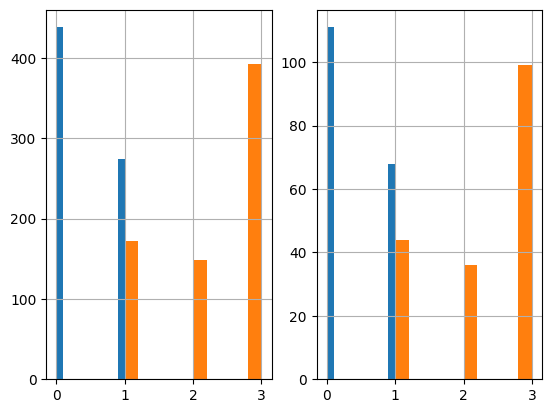

In [48]:
plt.subplot(1,2,1)
strat_train_set['Survived'].hist()
strat_train_set['Pclass'].hist()

plt.subplot(1,2,2)
strat_test_set['Survived'].hist()
strat_test_set['Pclass'].hist()
plt.show()


In [49]:
strat_train_set.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 712 entries, 756 to 404
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  712 non-null    int64  
 1   Survived     712 non-null    int64  
 2   Pclass       712 non-null    int64  
 3   Name         712 non-null    object 
 4   Sex          712 non-null    object 
 5   Age          567 non-null    float64
 6   SibSp        712 non-null    int64  
 7   Parch        712 non-null    int64  
 8   Ticket       712 non-null    object 
 9   Fare         712 non-null    float64
 10  Cabin        165 non-null    object 
 11  Embarked     710 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 72.3+ KB


In [50]:
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.impute import SimpleImputer

class AgeImputer(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        return self
    def transform(self,X):
        imputer=SimpleImputer(strategy='mean')
        X['Age']=imputer.fit_transform(X[['Age']])
        return X

In [51]:
from sklearn.preprocessing import OneHotEncoder
class FeatureEncoder(BaseEstimator,TransformerMixin):
    def fit(self,X,y=None):
        return self
    def transform(self,X):
        encoder=OneHotEncoder()
        matrix=encoder.fit_transform(X[["Embarked"]]).toarray()
        column_names=["C","S","Q","N"]
        for i in range(len(matrix.T)):
            X[column_names[i]]=matrix.T[i]
        matrix=encoder.fit_transform(X[["Sex"]]).toarray()
        column_names=["Female","Male"]
        for i in range(len(matrix.T)):
            X[column_names[i]]=matrix.T[i]
        return X
    

In [52]:
class FeatureDropper(BaseEstimator,TransformerMixin):
     def fit(self,X,y=None):
        return self 
     def transform(self,X):
        return X.drop(["Embarked","Name","Ticket","Cabin","Sex","N"],axis=1,errors='ignore')

In [53]:
from sklearn.pipeline import Pipeline
pipeline=Pipeline([('ageimputer', AgeImputer()),
                   ('featureencoder',FeatureEncoder()),
                   ('featuredropper',FeatureDropper())])

In [54]:
strat_train_set=pipeline.fit_transform(strat_train_set)

In [55]:
strat_train_set

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare,C,S,Q,Female,Male
756,757,0,3,28.00000,0,0,7.7958,0.0,0.0,1.0,0.0,1.0
50,51,0,3,7.00000,4,1,39.6875,0.0,0.0,1.0,0.0,1.0
792,793,0,3,30.07746,8,2,69.5500,0.0,0.0,1.0,1.0,0.0
710,711,1,1,24.00000,0,0,49.5042,1.0,0.0,0.0,1.0,0.0
378,379,0,3,20.00000,0,0,4.0125,1.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...
109,110,1,3,30.07746,1,0,24.1500,0.0,1.0,0.0,1.0,0.0
353,354,0,3,25.00000,1,0,17.8000,0.0,0.0,1.0,0.0,1.0
347,348,1,3,30.07746,1,0,16.1000,0.0,0.0,1.0,1.0,0.0
861,862,0,2,21.00000,1,0,11.5000,0.0,0.0,1.0,0.0,1.0


In [56]:
strat_train_set.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 712 entries, 756 to 404
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  712 non-null    int64  
 1   Survived     712 non-null    int64  
 2   Pclass       712 non-null    int64  
 3   Age          712 non-null    float64
 4   SibSp        712 non-null    int64  
 5   Parch        712 non-null    int64  
 6   Fare         712 non-null    float64
 7   C            712 non-null    float64
 8   S            712 non-null    float64
 9   Q            712 non-null    float64
 10  Female       712 non-null    float64
 11  Male         712 non-null    float64
dtypes: float64(7), int64(5)
memory usage: 72.3 KB


In [57]:
from sklearn.preprocessing import StandardScaler
X=strat_train_set.drop(['Survived'],axis=1)
y=strat_train_set['Survived']
scaler=StandardScaler()
X_data=scaler.fit_transform(X)
y_data=y.to_numpy()

In [58]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
clf=RandomForestClassifier()
param_grid=[
    {"n_estimators": [10,100,200,500], "max_depth": [ None,5,10], "min_samples_split": [2,3,4]}
]
grid_search= GridSearchCV(clf, param_grid, cv=3, scoring='accuracy', return_train_score=True)
grid_search.fit(X_data,y_data)

GridSearchCV(cv=3, estimator=RandomForestClassifier(),
             param_grid=[{'max_depth': [None, 5, 10],
                          'min_samples_split': [2, 3, 4],
                          'n_estimators': [10, 100, 200, 500]}],
             return_train_score=True, scoring='accuracy')

In [59]:
final_clf=grid_search.best_estimator_

In [60]:
final_clf

RandomForestClassifier(max_depth=5, min_samples_split=4)

In [61]:
start_test_set=pipeline.fit_transform(strat_test_set)

In [62]:
X_test = strat_test_set.drop(['Survived'], axis=1)
y_test = strat_test_set['Survived']

scaler = StandardScaler()
X_data_test = scaler.fit_transform(X_test)
y_data_test = y_test.to_numpy()

ValueError: could not convert string to float: 'Connolly, Miss. Kate'

In [ ]:
final_clf.score(scaler.fit_transform(X_test) ,y_data_test)